In [6]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
import numpy as np
from sklearn.neighbors import KernelDensity

def cluster_by_kde_contours(X_decomp, kde, n_groups, min_cluster_len=100):

    X, Y = np.meshgrid(
        np.linspace(-1.01, 1.01, 100), 
        np.linspace(-1.01, 1.01, 100)
    )
    Z = np.vstack([Y.ravel(), X.ravel()]).T
    # density at gridpoints
    Z = np.exp(kde.score_samples(Z)).reshape(X.shape)

    levels = np.linspace(Z.min(), Z.max(), n_groups+2)

    fig, ax = plt.subplots()
    contours = ax.contourf(X, Y, Z, levels=levels)
    plt.close(fig)

    # contour polygon containment clustering
    cluster_labels = np.full(X_decomp.shape[0], fill_value=-1)
    for cluster_id, path in enumerate(contours.get_paths()):
            poly = Path(path.vertices)
            inside = poly.contains_points(X_decomp)
            cluster_labels[inside] = cluster_id
            
    # if cluster size is smaller than minimum, combine it with the next cluster along
    smallest_cluster_len = -np.inf
    while smallest_cluster_len < min_cluster_len:
        cluster_lens = []
        for i in np.unique(cluster_labels):
            c_idxs = np.where(cluster_labels==i)[0]
            c_len = len(c_idxs)
            cluster_lens.append(c_len)
            if c_len < min_cluster_len:
                for j in c_idxs:
                    cluster_labels[j] = i+1

        smallest_cluster_len = min(cluster_lens)
                    
    # Alternative fast binning by quantiles (doesn't match contours exactly, but is cheap)
    #thresholds = np.quantile(density, np.linspace(0, 1, n_groups + 1))
    #cluster_labels = np.digitize(density, thresholds[1:], right=True)
    
    return Z, contours, cluster_labels, cluster_lens

def plot_decomp_kde_2D_clustered(X, Z, ax, cluster_labels, cluster_lens):
    """ Plot decomposition with KDE contours
        color X by cluster label
        plot a mini bar graph on top of the axes for cluster lens
    """
    xx, yy = np.meshgrid(
        np.linspace(-1.01, 1.01, 100), 
        np.linspace(-1.01, 1.01, 100)
    )

    levels = np.linspace(Z.min(), Z.max(), 12)
    ax.contourf(xx, yy, Z, levels=levels, cmap=plt.cm.Reds)
    ax.scatter(X[:,0], X[:,1], s=5, c=cluster_labels, cmap="viridis")
    ax.grid(True)

    inset_ax = ax.inset_axes([0.1, 1.05, 0.8, 0.2])
    inset_ax.bar(np.unique(cluster_labels), cluster_lens, color="blue", alpha=0.7)    
    inset_ax.set_ylabel("Cluster Size")

    return

In [59]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.pipeline import Pipeline
from sklearn.decomposition import KernelPCA
from sklearn.manifold import Isomap
from sklearn.preprocessing import MinMaxScaler


smi_file = "/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/scratch_programs/fp_decomp_kde/fp_decomp_testing_pipeline/data/hydros8992.smi"

smis = [i.strip() for i in open(smi_file).readlines()]
fpgen = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=2048)
#fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = np.array([fpgen.GetFingerprint(Chem.MolFromSmiles(s)) for s in smis])

pipe = Pipeline([("decomp", Isomap(n_components=2)), ("scaler", MinMaxScaler((-1, 1)))])
#pipe = Pipeline([("decomp", KernelPCA(n_components=2, kernel="rbf")), ("scaler", MinMaxScaler((-1, 1)))])

X = pipe.fit_transform(fps)

/home/andyt/miniconda3/envs/regression_sandbox/lib/python3.9/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 3 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/home/andyt/miniconda3/envs/regression_sandbox/lib/python3.9/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/andyt/miniconda3/envs/regression_sandbox/lib/python3.9/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/home/andyt/miniconda3/envs/regression_sandbox/lib/python3.9/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure 

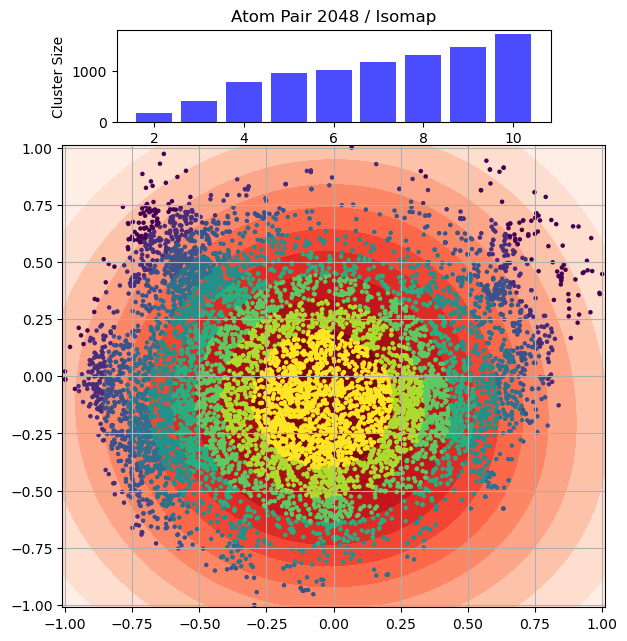

In [74]:
kde = KernelDensity(kernel="gaussian", bandwidth=0.5)
kde.fit(X)
Z, contours, cluster_labels, cluster_lens = cluster_by_kde_contours(X, kde, 10, min_cluster_len=100)

fig, ax = plt.subplots(figsize=(7,6))
plot_decomp_kde_2D_clustered(X, Z, ax, cluster_labels, cluster_lens)
ax.set_title("Atom Pair 2048 / Isomap")
plt.show()

5 cluster labels: [1 2 3 4 5]
6 cluster labels: [1 2 3 4 5 6]
7 cluster labels: [2 3 4 5 6 7]
8 cluster labels: [2 3 4 5 6 7 8]
9 cluster labels: [2 3 4 5 6 7 8 9]
10 cluster labels: [ 2  3  4  5  6  7  8  9 10]
15 cluster labels: [ 4  5  6  7  8  9 10 11 12 13 14 15]
20 cluster labels: [ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
25 cluster labels: [ 6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
30 cluster labels: [ 7  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30]
35 cluster labels: [ 9 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33
 34 35]
40 cluster labels: [10 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34
 35 36 37 38 39 40]
45 cluster labels: [11 13 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36
 37 38 39 40 41 42 43 44 45]
50 cluster labels: [13 15 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38
 39 40 41 42 43 44 45 46 47 48 49 50]
55 cluster labels: [14 16 18

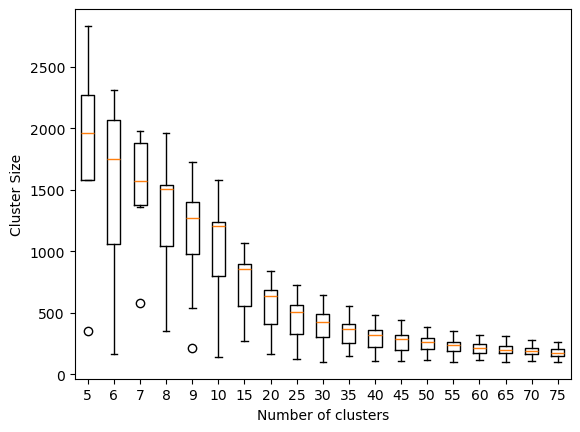

In [52]:
cluster_sizes = {}
n_clusters_to_test = [5, 6, 7, 8, 9] + list(range(10, 80, 5))
for n_groups in n_clusters_to_test:
    Z, contours, cluster_labels, cluster_lens = cluster_by_kde_contours(X, kde, n_groups, min_cluster_len=100)
    print(n_groups, "cluster labels:", np.unique(cluster_labels))
    cluster_sizes[n_groups] = cluster_lens

fig, ax = plt.subplots()
ax.boxplot(cluster_sizes.values(),
           tick_labels=cluster_sizes.keys())
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Cluster Size")
plt.show()

In [57]:
# As we only have 10,000 mols, we should use a 20% training set (10% is applied to sets > 100,000)
# As we are training for robustness primarily, take equally from each cluster
import random

val_split = 0.2
n_clusters = 10
Z, contours, cluster_labels, cluster_lens = cluster_by_kde_contours(X, kde, n_clusters, min_cluster_len=100)
val_set_idxs = []

empty_clusters = 0
for i in range(1, n_clusters+1):
    if len(np.where(cluster_labels==i)[0]) < int((len(cluster_labels)/n_clusters)*0.2):
        empty_clusters += 1

samples_per_cluster = int((len(cluster_labels)/(n_clusters-empty_clusters))*0.2)
print(samples_per_cluster, "samples per cluster")

for i in range(1, n_clusters+1):
    # If not in a cluster, leave out of the validation set
    if len(np.where(cluster_labels==i)[0]) > samples_per_cluster:
        val_set_idxs.extend(random.sample(list(np.where(cluster_labels==i)[0]), samples_per_cluster))
print(len(val_set_idxs), "validation set members")

224 samples per cluster
1792 validation set members


In [58]:
with open("val_set_idxs_kde_clusters.txt", "w") as fw:
    for i in val_set_idxs:
         fw.write(f"{i}\n")

In [69]:
# Get weights to even the emphasis of training based on the kde contour distribution
from sklearn.utils import class_weight
import pandas as pd

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(cluster_labels),l
    y=cluster_labels
)

# dictionary to pass to class_weight argument in keras model.fit
class_weight_dict = dict(enumerate(class_weights, min(np.unique(cluster_labels))))

sample_weights = np.array([class_weight_dict[i] for i in cluster_labels])

display(pd.DataFrame(sample_weights).value_counts())
display(class_weight_dict)

0       
0.584276    1710
0.681057    1467
0.766778    1303
0.853941    1170
0.980482    1019
1.039658     961
1.289176     775
2.407497     415
5.808786     172
Name: count, dtype: int64

{2: 5.808785529715762,
 3: 2.407496653279786,
 4: 1.2891756272401433,
 5: 1.0396577639033415,
 6: 0.9804819539853887,
 7: 0.8539411206077873,
 8: 0.766777521957875,
 9: 0.6810573354540634,
 10: 0.5842755035737491}

In [70]:
np.save("sample_weights_hydros8992.npy", sample_weights)

In [72]:
# DATASET AUGMENTATION:
# enumerate SMILES strings from smaller clusters to balance
import math

new_smis_train = []
for count, smi in enumerate(smis):
    mol = Chem.MolFromSmiles(smi)
    
    # calculate number of smis to enumerate
    weight = class_weight_dict[cluster_labels[count]]
    smis_to_enumerate = 1
    if weight > 1.0:
        smis_to_enumerate = math.ceil(weight)
    else:
        new_smis_train.append(smi)
        continue
    
    enumerated_smis = []
    for i in range(smis_to_enumerate):
        new_smi = Chem.MolToSmiles(mol, doRandom=True)
        if new_smi not in enumerated_smis:
            enumerated_smis.append(new_smi)
            
    new_smis_train.extend(enumerated_smis)
    
len(new_smis_train)

12405

In [73]:
with open("augmented_by_kde_clusters_hydros8992.smi", "w") as fw:
    for smi in new_smis_train:
        fw.write(f"{smi}\n")

In [77]:
import pickle

pipeout = "HC8992_atom_pair_isomap_pipe.pkl"
kdeout = "HC8992_atom_pair_isomap_kde.pkl"

with open(pipeout, "wb") as fw:
    pickle.dump(pipe, fw)

with open(kdeout, "wb") as fw:
    pickle.dump(kde, fw)